# Lecture 6: The Recommendation Problem

> *"The basic idea of recommender systems is to utilize these various sources of data to infer customer interests."*
> — Aggarwal, *Recommender Systems: The Textbook* (2016)

In [1]:
# Setup — run this first
%pip install pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import urllib.request, zipfile, os

plt.rcParams.update({
    'figure.figsize': (9, 5),       # slide-friendly default
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 12,
})

if not os.path.exists('ml-latest-small'):
    urllib.request.urlretrieve('https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'ml.zip')
    with zipfile.ZipFile('ml.zip','r') as z: z.extractall('.')

ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies  = pd.read_csv('ml-latest-small/movies.csv')
print(f'Loaded {len(ratings):,} ratings  |  {ratings["userId"].nunique()} users  |  {ratings["movieId"].nunique()} movies')

/Users/scydal/git/data-science-workflow/DSA/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


Loaded 100,836 ratings  |  610 users  |  9724 movies


## What does recommendation look like in the real world?

- **Netflix**: ~80 % of watched content comes from recommendations
- **Amazon**: ~35 % of revenue attributed to recommendations
- **YouTube**: ~70 % of watch time from recommendations

Recommendation **is** the product.

<small><em>Sources: Netflix — Gomez-Uribe & Hunt, <em>ACM TMIS</em> (2015); Amazon — McKinsey (2013); YouTube — Solsman, <em>CNET</em> (2018).</em></small>

## A bit of formalism

The same idea in symbols — these are the variables you'll meet in every recommender-systems paper or textbook (Aggarwal 2016, Falk 2018):

- $U = \{u_1, u_2, \dots, u_n\}$ — set of $n$ **users**
- $I = \{i_1, i_2, \dots, i_m\}$ — set of $m$ **items**
- $R \in \mathbb{R}^{n \times m}$ — the **rating matrix**, where $r_{u,i}$ is the rating user $u$ gave item $i$ (or $\texttt{NaN}$ if missing)

A recommender system solves one of two tasks:

| Task | What | As a function |
|---|---|---|
| **Rating prediction** | Fill in the missing $r_{u,i}$ | $p : U \times I \to \mathbb{R}$ &nbsp;(regression) &nbsp;or&nbsp; $p : U \times I \to C$ &nbsp;(classification) |
| **Ranking prediction** | For user $u$, return the top-$k$ items they'll like most | $\text{top-}k : U \to I^k$ |

Ranking can be *reduced to* rating prediction — predict every score, then sort — but it's often optimized directly, and a low rating-prediction error (RMSE) does **not** guarantee a good ranking.

## The Rating Matrix

Every recommender system is built on a **rating matrix**: rows = users, columns = items, values = ratings (mostly missing).

### MovieLens (small) at a glance

The concrete dataset behind every plot in this lecture.

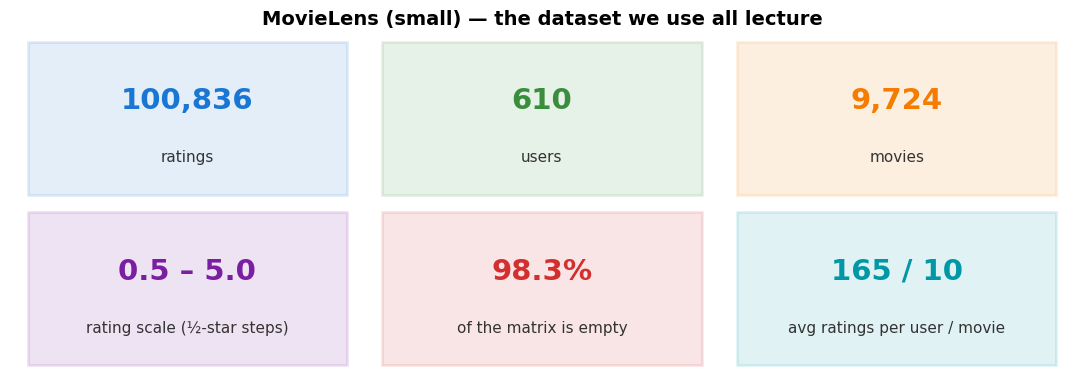

In [2]:
# --- dataset stat cards ---
n_ratings = len(ratings)
n_users   = ratings['userId'].nunique()
n_movies  = ratings['movieId'].nunique()
sparsity  = 1 - n_ratings / (n_users * n_movies)
avg_u, avg_m = n_ratings / n_users, n_ratings / n_movies

cards = [
    (f'{n_ratings:,}',          'ratings',                      '#1976d2'),
    (f'{n_users:,}',            'users',                        '#388e3c'),
    (f'{n_movies:,}',           'movies',                       '#f57c00'),
    ('0.5 – 5.0',               'rating scale (½-star steps)',  '#7b1fa2'),
    (f'{sparsity:.1%}',         'of the matrix is empty',       '#d32f2f'),
    (f'{avg_u:.0f} / {avg_m:.0f}', 'avg ratings per user / movie', '#0097a7'),
]
fig, ax = plt.subplots(figsize=(11, 4)); ax.axis('off')
ax.set_xlim(0, 3); ax.set_ylim(0, 2)
for idx, (num, lab, col) in enumerate(cards):
    cx, cy = idx % 3, 1 - idx // 3
    ax.add_patch(plt.Rectangle((cx + 0.05, cy + 0.05), 0.9, 0.9,
                 facecolor=col, alpha=0.12, edgecolor=col, lw=2))
    ax.text(cx + 0.5, cy + 0.60, num, ha='center', va='center',
            fontsize=21, fontweight='bold', color=col)
    ax.text(cx + 0.5, cy + 0.27, lab, ha='center', va='center', fontsize=11, color='#333')
ax.set_title('MovieLens (small) — the dataset we use all lecture', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [3]:
# Build the rating matrix once for the rest of the lecture
R = ratings.pivot_table(index='userId', columns='movieId', values='rating')

### A small corner — what real ratings look like

Twelve users × twelve movies. Coloured cells are actual star ratings (0.5 – 5). White cells are missing — nobody rated those.

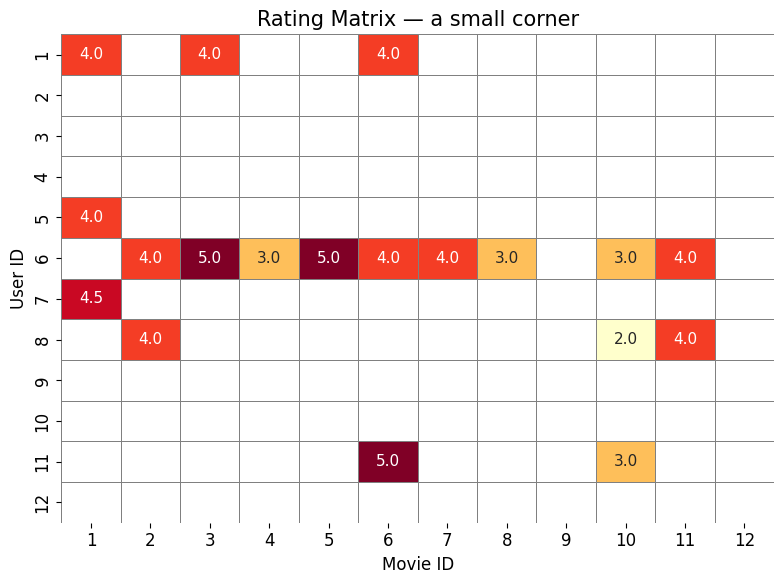

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
small = R.iloc[:12, :12]
sns.heatmap(small, annot=True, fmt='.1f', cmap='YlOrRd', cbar=False,
            linewidths=0.5, linecolor='gray', ax=ax,
            mask=small.isna(), annot_kws={'size': 11})
ax.set_title('Rating Matrix — a small corner')
ax.set_xlabel('Movie ID'); ax.set_ylabel('User ID')
plt.tight_layout(); plt.show()

### Zooming out — where do we have ratings *at all*?

Now 80 users × 200 movies. Each black dot is a rating that exists; white is missing. **Most of the space is empty** — that's the core challenge of recommendation.

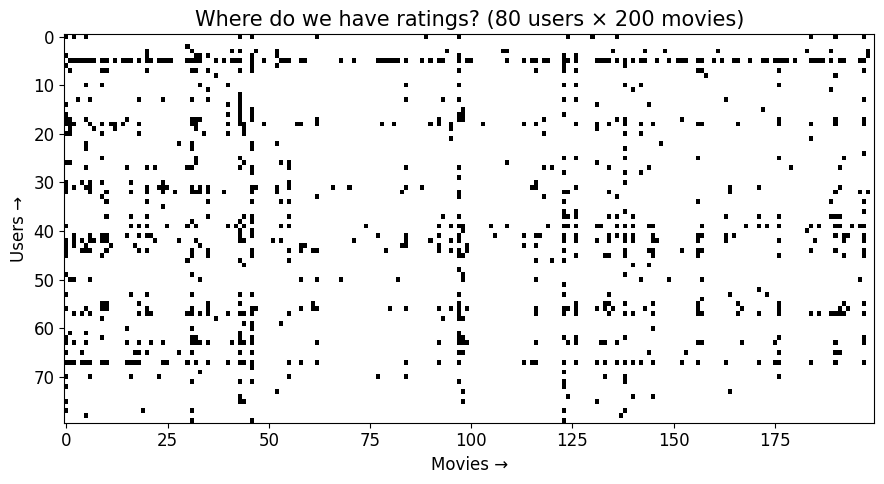

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sample_R = R.iloc[:80, :200]
ax.imshow(~sample_R.isna(), cmap='Greys', aspect='auto', interpolation='none')
ax.set_title('Where do we have ratings? (80 users × 200 movies)')
ax.set_xlabel('Movies →'); ax.set_ylabel('Users →')
plt.tight_layout(); plt.show()

## Types of Feedback

Ratings aren't the only signal. Users leave traces in many forms — each shapes how the matrix is built.

### Explicit feedback — star ratings

The user gives an explicit numeric score — the cleanest signal, but expensive to collect (most users never rate). And the scores that *do* arrive are **skewed high**: people mostly rate things they already liked (a selection bias).

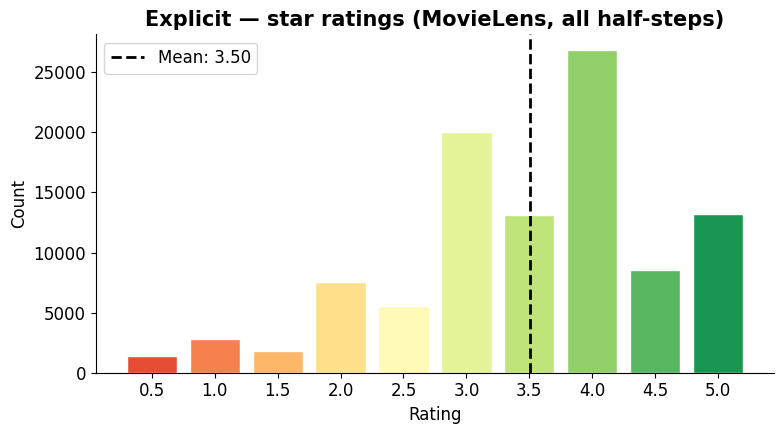

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
# all ten half-star levels (0.5 ... 5.0) -- not just whole stars
vc = ratings['rating'].value_counts().sort_index()
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(vc)))
ax.bar(vc.index, vc.values, width=0.4, color=colors, edgecolor='white')
mean_r = ratings['rating'].mean()
ax.axvline(mean_r, color='black', linestyle='--', linewidth=2, label=f'Mean: {mean_r:.2f}')
ax.set_title('Explicit — star ratings (MovieLens, all half-steps)', fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Count')
ax.set_xticks(np.arange(0.5, 5.5, 0.5))
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### Implicit feedback — clicks, time spent, page views

The user never explicitly rates anything — we infer interest from behaviour. Much more abundant, but noisier (a click isn't a "like").

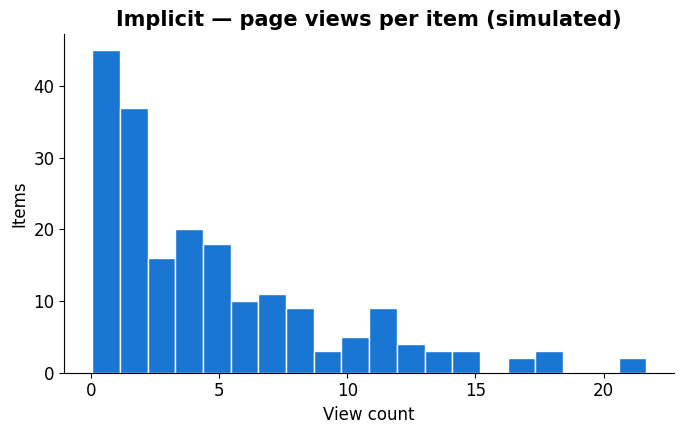

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
np.random.seed(42)
views = np.random.exponential(5, 200)
ax.hist(views, bins=20, color='#1976d2', edgecolor='white')
ax.set_title('Implicit — page views per item (simulated)', fontweight='bold')
ax.set_xlabel('View count'); ax.set_ylabel('Items')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### Binary feedback — like / dislike

Thumbs up or down only. Throws away rating *magnitude* but is much easier for users — and matches how YouTube and Spotify now work.

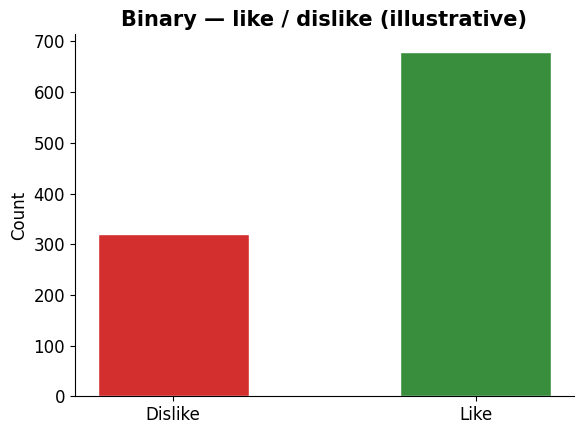

In [8]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(['Dislike', 'Like'], [320, 680], color=['#d32f2f', '#388e3c'], edgecolor='white', width=0.5)
ax.set_title('Binary — like / dislike (illustrative)', fontweight='bold')
ax.set_ylabel('Count')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### Ordinal feedback — categories with order

Bad / neutral / good — fewer levels than stars, more nuance than binary. Common in surveys and quick UI polls.

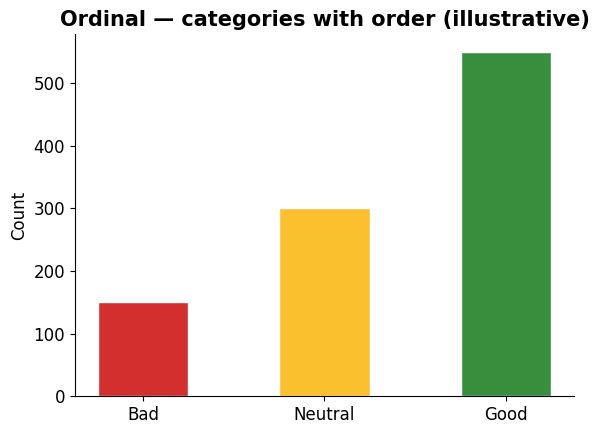

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(['Bad', 'Neutral', 'Good'], [150, 300, 550],
       color=['#d32f2f','#fbc02d','#388e3c'], edgecolor='white', width=0.5)
ax.set_title('Ordinal — categories with order (illustrative)', fontweight='bold')
ax.set_ylabel('Count')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Different Data Modalities

Recommendations involve more than numbers. We work with **text**, **images**, and **tabular** data — each needs a different strategy to become a computable vector.

### Text data — e.g. review word frequencies

Words become numbers via word counts, TF-IDF, or (later in the course) sentence-embedding vectors.

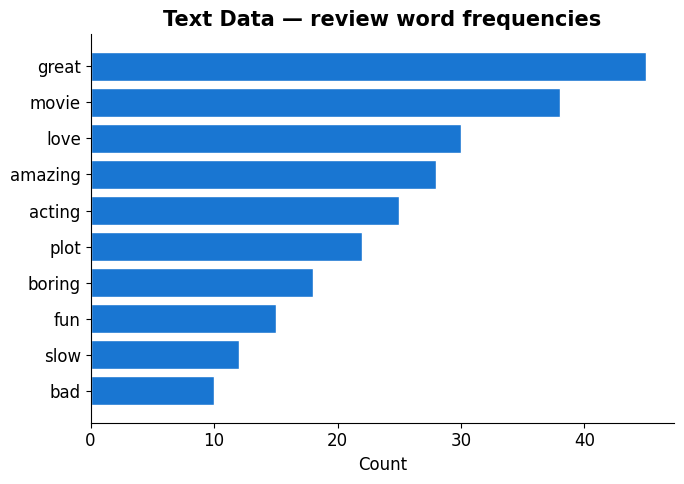

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
words = ['great','movie','acting','plot','boring','love','fun','slow','amazing','bad']
freq  = [45, 38, 25, 22, 18, 30, 15, 12, 28, 10]
order = np.argsort(freq)                       # smallest first -> largest ends on top
words = [words[i] for i in order]; freq = [freq[i] for i in order]
ax.barh(words, freq, color='#1976d2', edgecolor='white')
ax.set_title('Text Data — review word frequencies', fontweight='bold')
ax.set_xlabel('Count')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### Image data — e.g. a painting → pixel values

An image is a **3-D array**: **height × width × 3 colour channels** (red, green, blue). Every pixel stores 3 numbers — the painting below is a $760 \times 960 \times 3$ grid of values.

*Isn't there a saturation/brightness channel?* Not in RGB. Saturation and brightness are the axes of a **different** 3-channel encoding, **HSV** (Hue, **S**aturation, **V**alue = brightness) — the same image, just re-encoded. Images can also carry a 4th **alpha** (transparency) channel → RGBA.

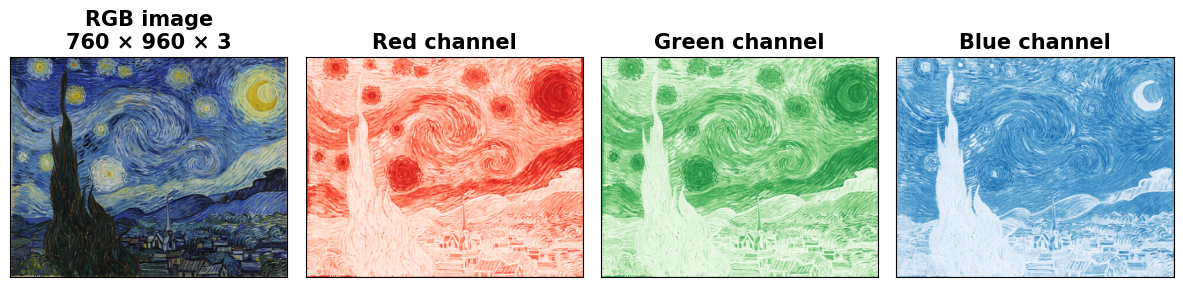

In [11]:
# a real, recognisable image split into its three colour channels
import matplotlib.cbook as cbook, os
photo = None
for p in ['../figures/starry_night.jpg', 'figures/starry_night.jpg', 'starry_night.jpg']:
    if os.path.exists(p):
        photo = plt.imread(p); break
if photo is None:                       # fallback so the build never breaks
    photo = plt.imread(cbook.get_sample_data('grace_hopper.jpg', asfileobj=True))

fig, axes = plt.subplots(1, 4, figsize=(12, 3.6))
axes[0].imshow(photo)
axes[0].set_title(f'RGB image\n{photo.shape[0]} × {photo.shape[1]} × 3', fontweight='bold')
for k, (name, cm) in enumerate(zip(['Red', 'Green', 'Blue'], ['Reds', 'Greens', 'Blues']), start=1):
    axes[k].imshow(photo[:, :, k-1], cmap=cm, vmin=0, vmax=255)
    axes[k].set_title(f'{name} channel', fontweight='bold')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### Tabular / ordinal data — e.g. genre scores per item

Hand-crafted attribute vectors. The most direct form — every column is already a number.

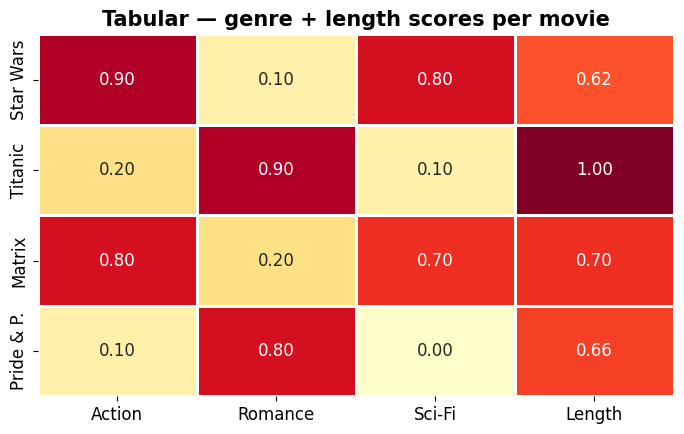

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
# Illustrative attribute vectors. Length = runtime / longest runtime (Titanic, 195 min):
# Star Wars 121, Titanic 195, Matrix 136, Pride & Prejudice 129 (minutes)
table_data = pd.DataFrame({
    'Action':  [0.9, 0.2, 0.8, 0.1],
    'Romance': [0.1, 0.9, 0.2, 0.8],
    'Sci-Fi':  [0.8, 0.1, 0.7, 0.0],
    'Length':  [0.62, 1.00, 0.70, 0.66],
}, index=['Star Wars', 'Titanic', 'Matrix', 'Pride & P.'])
sns.heatmap(table_data, annot=True, cmap='YlOrRd', cbar=False, ax=ax,
            linewidths=1, linecolor='white', fmt='.2f')
ax.set_title('Tabular — genre + length scores per movie', fontweight='bold')
plt.tight_layout(); plt.show()

Each modality needs its own strategy to turn into a vector.

## Problem 1: Sparsity

We just saw the matrix looks mostly empty — now let's put a number on it. How much of the MovieLens rating matrix is actually filled?

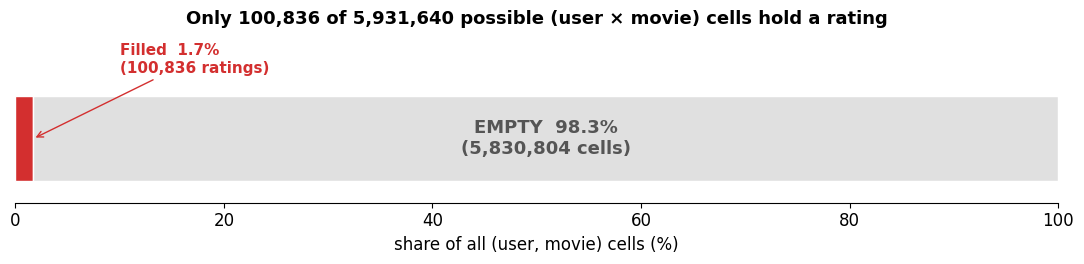

→ 98.3% of the matrix is empty. Standard ML methods can't handle this directly.


In [13]:
total  = R.shape[0] * R.shape[1]
filled = int(R.notna().sum().sum())
empty  = total - filled
sparsity = empty / total

fig, ax = plt.subplots(figsize=(11, 2.8))
fp = filled / total * 100
ax.barh([0], [fp], color='#d32f2f', edgecolor='white')
ax.barh([0], [100 - fp], left=[fp], color='#e0e0e0', edgecolor='white')
ax.set_xlim(0, 100); ax.set_ylim(-0.6, 1.0); ax.set_yticks([])
ax.set_xlabel('share of all (user, movie) cells (%)')
ax.text(fp + (100 - fp) / 2, 0, f'EMPTY  {sparsity:.1%}\n({empty:,} cells)',
        ha='center', va='center', fontsize=13, color='#555', fontweight='bold')
ax.annotate(f'Filled  {1 - sparsity:.1%}\n({filled:,} ratings)',
            xy=(fp, 0.0), xytext=(10, 0.62), fontsize=11, color='#d32f2f', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d32f2f'))
ax.set_title(f'Only {filled:,} of {total:,} possible (user × movie) cells hold a rating',
             fontsize=13, fontweight='bold')
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout(); plt.show()
print(f'→ {sparsity:.1%} of the matrix is empty. Standard ML methods can\'t handle this directly.')

## Problem 2: The Long Tail

A handful of popular items get most of the ratings. The vast majority — the "long tail" — get very few.

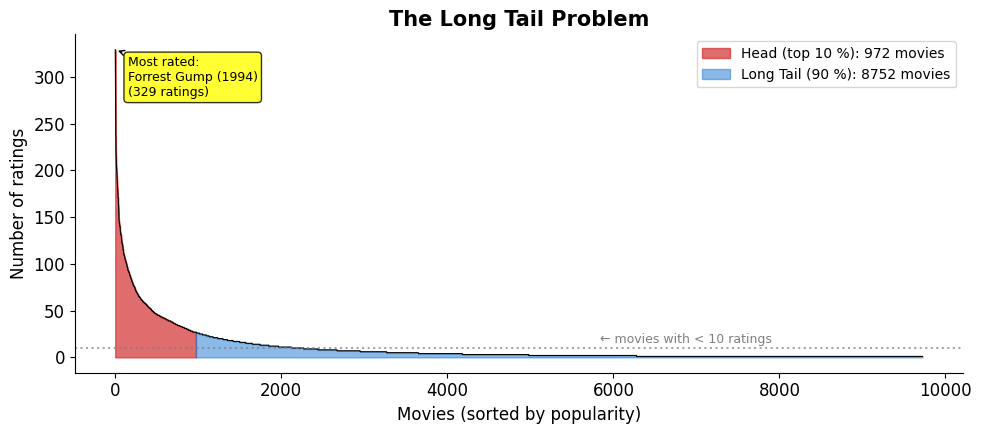

→ 7455 of 9724 movies (77%) have < 10 ratings.


In [14]:
ratings_per_movie = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = range(len(ratings_per_movie)); y = ratings_per_movie.values
head_cutoff = int(len(y) * 0.1)
ax.fill_between(x[:head_cutoff], y[:head_cutoff], alpha=0.7, color='#d32f2f',
                label=f'Head (top 10 %): {head_cutoff} movies')
ax.fill_between(x[head_cutoff:], y[head_cutoff:], alpha=0.5, color='#1976d2',
                label=f'Long Tail (90 %): {len(y)-head_cutoff} movies')
ax.plot(x, y, color='black', linewidth=0.8)

top_movie_id = ratings_per_movie.index[0]
top_title = movies[movies['movieId']==top_movie_id]['title'].values[0]
ax.annotate(f'Most rated:\n{top_title[:30]}\n({y[0]} ratings)',
            xy=(0, y[0]), xytext=(150, y[0]*0.85),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))
ax.axhline(y=10, color='gray', linestyle=':', alpha=0.7)
ax.text(len(y)*0.6, 15, '← movies with < 10 ratings', fontsize=9, color='gray')
ax.set_title('The Long Tail Problem', fontsize=15, fontweight='bold')
ax.set_xlabel('Movies (sorted by popularity)')
ax.set_ylabel('Number of ratings')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

tail = (ratings_per_movie < 10).sum()
print(f'→ {tail} of {len(ratings_per_movie)} movies ({tail/len(ratings_per_movie):.0%}) have < 10 ratings.')

## Problem 3: Cold Start

What happens when a *user* or an *item* is brand new — no rating history at all?

### What cold start looks like in the matrix

A brand-new **user** is an empty *row*; a brand-new **item** is an empty *column*. There is nothing to learn from.

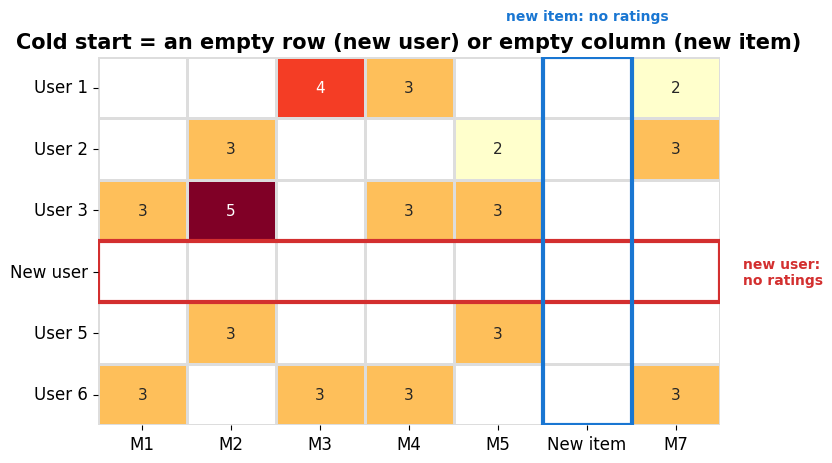

In [15]:
# --- cold-start illustration: one empty row + one empty column ---
rng = np.random.default_rng(3)
CS = rng.choice([np.nan, 2, 3, 4, 5], size=(6, 7), p=[0.4, 0.15, 0.2, 0.15, 0.1]).astype(float)
CS[3, :] = np.nan      # new user  -> whole row empty
CS[:, 5] = np.nan      # new item  -> whole column empty
ulabels = [f'User {i+1}' for i in range(6)]; ulabels[3] = 'New user'
mlabels = [f'M{i+1}' for i in range(7)];     mlabels[5] = 'New item'

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.heatmap(CS, annot=True, fmt='.0f', cmap='YlOrRd', cbar=False, mask=np.isnan(CS),
            xticklabels=mlabels, yticklabels=ulabels,
            linewidths=1, linecolor='#ddd', ax=ax, annot_kws={'size': 11})
ax.add_patch(plt.Rectangle((0, 3), 7, 1, fill=False, edgecolor='#d32f2f', lw=3))
ax.add_patch(plt.Rectangle((5, 0), 1, 6, fill=False, edgecolor='#1976d2', lw=3))
# annotations placed clear of the tick labels
ax.text(7.25, 3.5, 'new user:\nno ratings', color='#d32f2f', va='center', ha='left',
        fontsize=10, fontweight='bold')
ax.text(5.5, -0.55, 'new item: no ratings', color='#1976d2', ha='center', va='bottom',
        fontsize=10, fontweight='bold')
ax.set_title('Cold start = an empty row (new user) or empty column (new item)', fontweight='bold')
plt.tight_layout(); plt.show()

### Cold-start users? Not in *this* dataset

MovieLens-small only keeps users who have rated **at least 20 movies**, so it has **no** cold-start users by construction. Real systems aren't so lucky — we'll simulate a brand-new user in the CF example later.

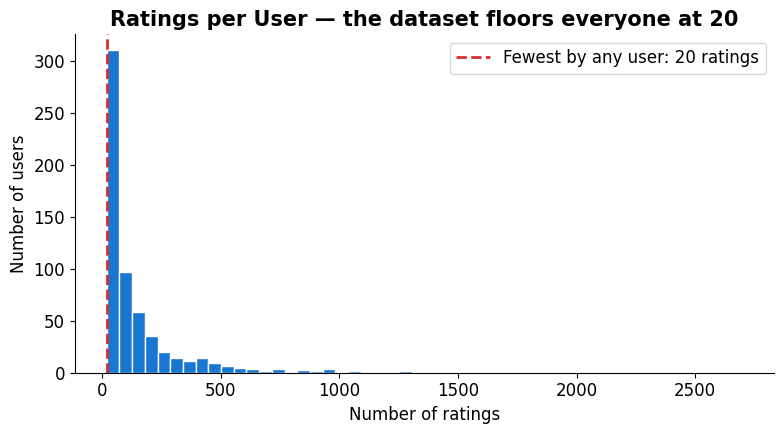

→ Minimum ratings by any user: 20. MovieLens filters cold-start users out.


In [16]:
ratings_per_user = ratings.groupby('userId')['rating'].count()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(ratings_per_user, bins=50, color='#1976d2', edgecolor='white')
ax.axvline(x=ratings_per_user.min(), color='#d32f2f', linestyle='--', linewidth=2,
           label=f'Fewest by any user: {ratings_per_user.min()} ratings')
ax.set_title('Ratings per User — the dataset floors everyone at 20', fontweight='bold')
ax.set_xlabel('Number of ratings'); ax.set_ylabel('Number of users')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f'→ Minimum ratings by any user: {ratings_per_user.min()}. MovieLens filters cold-start users out.')

### Cold-start items — these are real

Movies have no such floor: the least-rated have a single rating. **62 % of movies have fewer than 5 ratings** — far too few to learn from.

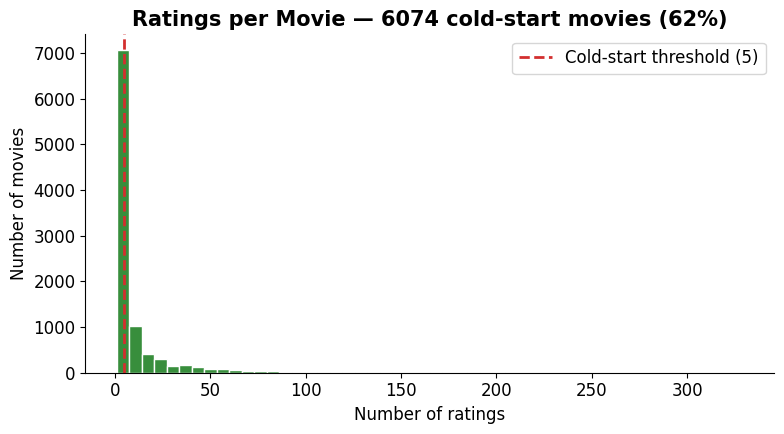

→ New users and rarely-rated movies: not enough data to make good predictions.


In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(ratings_per_movie, bins=50, color='#388e3c', edgecolor='white')
ax.axvline(x=5, color='#d32f2f', linestyle='--', linewidth=2, label='Cold-start threshold (5)')
cold_movies = (ratings_per_movie < 5).sum()
ax.set_title(f'Ratings per Movie — {cold_movies} cold-start movies ({cold_movies/len(ratings_per_movie):.0%})',
             fontweight='bold')
ax.set_xlabel('Number of ratings'); ax.set_ylabel('Number of movies')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print('→ New users and rarely-rated movies: not enough data to make good predictions.')

## The Netflix Prize — a $1M bounty on these problems

Sparsity, long tail, cold start — a real, costly problem. In **October 2006** Netflix turned it into the most famous ML competition in history.

| | |
|---|---|
| **Prize** | **$1,000,000** |
| Data | **100M ratings** · **480k users × 18k movies** |
| Sparsity | **~98.8 %** empty |
| Goal | beat *Cinematch* by **≥ 10 %** RMSE |
| Ran | **2006 – 2009** |

### Winner: *BellKor's Pragmatic Chaos*

No single magic algorithm — the winner **blended hundreds of models**:

- mostly **matrix factorization** variants (SVD++, timeSVD++, …) → *Lecture 8*
- plus **neighbourhood / k-NN** models (like the CF we just saw)
- plus early neural nets (**RBMs**)

Combined in layers (*"stacking"*). **Matrix factorization did the heavy lifting.**

<small><em>Precisely: a linear blend of hundreds of predictors — MF variants (SVD++, timeSVD++, asymmetric SVD, NSVD1, NNMF), neighbourhood/k-NN models and RBMs, stacked via gradient-boosted trees and other non-linear blenders.</em></small>

### The photo finish (2009)

Two scores, two stories — and the held-out **test set**, not the public leaderboard, is what paid out:

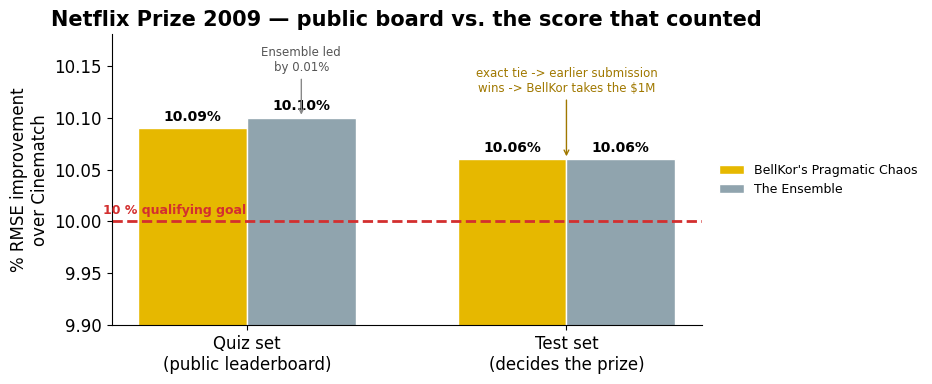

In [18]:
# --- Netflix Prize 2009: quiz set (public) vs test set (decides the prize) ---
groups   = ['Quiz set\n(public leaderboard)', 'Test set\n(decides the prize)']
bellkor  = [10.09, 10.06]
ensemble = [10.10, 10.06]
x = np.arange(2); w = 0.34

fig, ax = plt.subplots(figsize=(9.5, 4.0))
b1 = ax.bar(x - w/2, bellkor,  w, label="BellKor's Pragmatic Chaos", color='#e6b800', edgecolor='white')
b2 = ax.bar(x + w/2, ensemble, w, label='The Ensemble',              color='#90a4ae', edgecolor='white')

ax.axhline(10.0, color='#d32f2f', linestyle='--', lw=2)
ax.text(-0.45, 10.004, '10 % qualifying goal', color='#d32f2f', ha='left', va='bottom',
        fontsize=9, fontweight='bold')
ax.set_ylim(9.9, 10.18)
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel('% RMSE improvement\nover Cinematch')
ax.set_title('Netflix Prize 2009 — public board vs. the score that counted', fontweight='bold')

for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.004, f'{b.get_height():.2f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.annotate('Ensemble led\nby 0.01%', xy=(0.17, 10.10), xytext=(0.17, 10.145),
            fontsize=8.5, color='#555', ha='center', arrowprops=dict(arrowstyle='->', color='#888'))
ax.annotate('exact tie -> earlier submission\nwins -> BellKor takes the $1M', xy=(1.0, 10.06),
            xytext=(1.0, 10.125), fontsize=8.5, color='#a07800', ha='center',
            arrowprops=dict(arrowstyle='->', color='#a07800'))

ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## A First Attempt: Collaborative Filtering

Before we look at our roadmap, let's see what people tried **directly on the rating matrix**: **Collaborative Filtering (CF)**.

- **User-based CF:** *"Users who rated similarly to you also liked X"* — find your rating-twins, borrow their opinions
- **Item-based CF:** *"Movies that got similar ratings tend to be similar"* — if people who liked A also liked B, recommend B

This powered early Amazon and Netflix.

We'll work through **user-based CF** below; item-based is the same idea with the matrix transposed.

### A tiny example — can we predict the "?"

Four users, five movies. **You** haven't rated "Saw". Alice and Bob have similar taste to you; Carol's is opposite. What rating would you give?

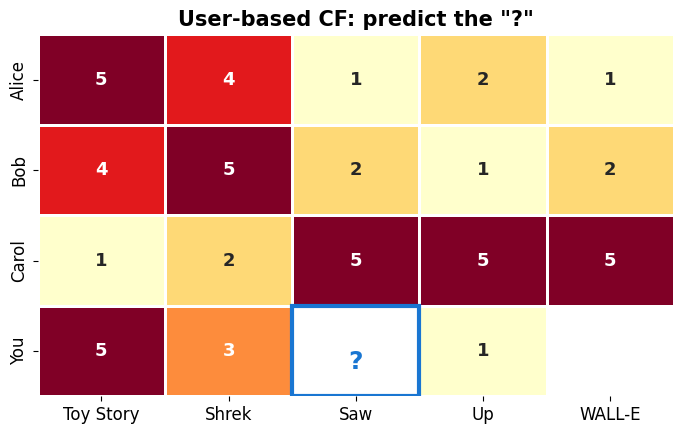

In [19]:
cf_users  = ['Alice', 'Bob', 'Carol', 'You']
cf_movies = ['Toy Story', 'Shrek', 'Saw', 'Up', 'WALL-E']
cf_data = np.array([
    [5,   4,   1,    2,   1],      # Alice
    [4,   5,   2,    1,   2],      # Bob
    [1,   2,   5,    5,   5],      # Carol
    [5,   3, np.nan, 1, np.nan],   # You
])

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(cf_data, annot=True, fmt='.0f', cmap='YlOrRd', cbar=False,
            linewidths=1, linecolor='white', ax=ax,
            xticklabels=cf_movies, yticklabels=cf_users,
            mask=np.isnan(cf_data), annot_kws={'size': 13, 'fontweight': 'bold'})
ax.add_patch(plt.Rectangle((2, 3), 1, 1, fill=False, edgecolor='#1976d2', lw=3))
ax.text(2.5, 3.75, '?', ha='center', va='bottom', fontsize=18, fontweight='bold', color='#1976d2')
ax.set_title('User-based CF: predict the "?"', fontweight='bold')
plt.tight_layout(); plt.show()

### Collaborative filtering in three steps

CF works directly on the rating matrix $R$ — no movie features needed:

1. *(offline)* **Compute similarity** for every user pair → fill the **user–user matrix** $\hat{U}$ (users × users), where $\hat{U}_{u,v} = \text{sim}(u, v)$.
2. *(online)* **Find neighbours:** take the target user's $k$ most similar users.
3. *(online)* **Predict** the missing rating from what those neighbours rated.

The whole game is **Step 1**: how do we define $\text{sim}(u, v)$?

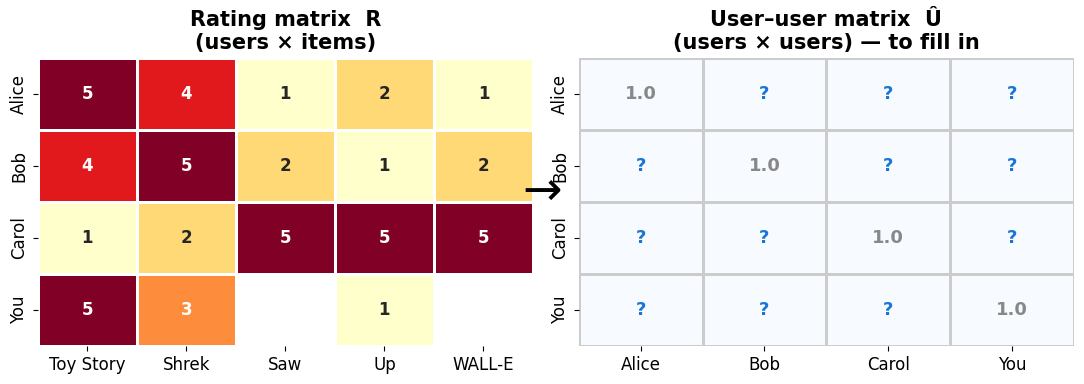

In [20]:
# --- schematic: rating matrix R  ->  user-user matrix U-hat ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cf_data, annot=True, fmt='.0f', cmap='YlOrRd', cbar=False, ax=axes[0],
            xticklabels=cf_movies, yticklabels=cf_users, mask=np.isnan(cf_data),
            linewidths=1, linecolor='white', annot_kws={'size': 12, 'fontweight': 'bold'})
axes[0].set_title('Rating matrix  R\n(users × items)', fontweight='bold')

sns.heatmap(np.zeros((4, 4)), cmap='Blues', vmin=0, vmax=1, cbar=False, ax=axes[1],
            xticklabels=cf_users, yticklabels=cf_users, linewidths=1, linecolor='#ccc')
for x in range(4):
    for y in range(4):
        txt = '1.0' if x == y else '?'
        axes[1].text(x + 0.5, y + 0.5, txt, ha='center', va='center',
                     fontsize=13, fontweight='bold', color='#888' if x == y else '#1976d2')
axes[1].set_title('User–user matrix  Û\n(users × users) — to fill in', fontweight='bold')
fig.text(0.5, 0.5, '→', fontsize=34, ha='center', va='center')
plt.tight_layout(); plt.show()

### Measuring similarity — attempt 1: dot product

Treat each user's ratings as a vector $r_u$ and take the **dot product**:

$$\text{sim}(u, v) = \langle r_u, r_v \rangle = \sum_i r_{u,i}\, r_{v,i}$$

❌ **Problem:** the matrix is mostly empty — for almost any pair, most items are rated by only one of them (or neither), so most products involve a missing value. The plain dot product isn't even well-defined.


### Fix 1 — only the items both users rated

Restrict the sum to the **common itemset** $I_{uv} = I_u \cap I_v$ (items *both* rated):

$$\text{sim}(u, v) = \sum_{i \in I_{uv}} r_{u,i}\, r_{v,i}$$

❌ **Problem: user bias.** A generous rater who gives everything 4–5 ★ looks similar to *everyone*. We're comparing rating *levels*, not *taste*.

### Fix 2 — subtract each user's average (de-bias)

Center each user on their own mean $\mu_u$, so we compare *deviations* from what is normal **for them**:

$$\text{sim}(u, v) = \sum_{i \in I_{uv}} (r_{u,i} - \mu_u)(r_{v,i} - \mu_v)$$

Now a grump and an enthusiast with the *same taste* line up. ❌ **Last problem:** the sum still grows with **scale** — the more items the two *co-rate*, or the more *extremely* they rate, the bigger it gets, regardless of how well they actually agree.


### Fix 3 — normalise → this *is* Pearson correlation

$$\text{sim}(u, v) = \frac{\langle r_u - \mu_u,\; r_v - \mu_v \rangle}{\lVert r_u - \mu_u \rVert \, \lVert r_v - \mu_v \rVert}$$

**Why divide by the lengths?** The raw sum on top isn't comparable between pairs: it gets bigger when the two users **co-rate more items** (more terms in the sum) or simply rate **more extremely** — neither of which means they actually agree *more*. Dividing by both vector lengths cancels that scale, putting every pair on the same $[-1, 1]$ footing — so we compare the **shape** of their agreement, not its size.

That's exactly the **cosine of the angle** between the two rating vectors — i.e. **Pearson correlation**: $+1$ identical taste, $0$ unrelated, $-1$ opposite.


### Step 1: Pearson's correlation coefficient

Written out over the common items $I_{uv}$:

$$
\text{sim}(u, v) \;=\; \frac{\displaystyle\sum_{i \in I_{uv}} (r_{u,i} - \mu_u)\,(r_{v,i} - \mu_v)}{\sqrt{\displaystyle\sum_{i \in I_{uv}} (r_{u,i} - \mu_u)^2}\;\sqrt{\displaystyle\sum_{i \in I_{uv}} (r_{v,i} - \mu_v)^2}}
$$

It's the statistician's $\rho_{X,Y} = \dfrac{\operatorname{cov}(X,Y)}{\sigma_X\,\sigma_Y}$ on the two users' co-rated ratings. **Intuition:** when you rate a film above *your* average, does $v$ tend to be above *theirs* too? Consistent agreement → near $+1$. Do this for every pair → the matrix $\hat{U}$.


### Step 2: find the top-$k$ nearest neighbours

With $\hat{U}$ filled in, the **peer group** $N_k(u)$ is just user $u$'s $k$ most similar users — k-nearest-neighbours on the similarity matrix.

| $\hat{U}$ | Alice | Bob | Carol |
|---|---|---|---|
| **You** | $+0.98$ | $+0.72$ | $-0.96$ |

For *You*, the nearest neighbours are **Alice and Bob**. (Our example is tiny, so we keep all three as the peer group — Carol's negative similarity simply pulls the estimate *down*.)

### Step 3: predict — a similarity-weighted average

First bundle the normaliser into **one weight per neighbour**, scaled by the total similarity so the weights' **magnitudes sum to 1**:

$$w_{u,v} \;=\; \frac{\text{sim}(u, v)}{\displaystyle\sum_{v' \in N_k(u)} |\text{sim}(u, v')|}$$

Now the prediction is just **your baseline + a weighted average of the neighbours' de-biased opinions**:

$$\hat{r}_{u,i} \;=\; \mu_u \;+\; \sum_{v \in N_k(u)} w_{u,v}\,(r_{v,i} - \mu_v)$$

A similar neighbour gets a large $w_{u,v}$; an *opposite*-taste one gets a **negative** weight that flips their vote. The term $r_{v,i} - \mu_v$ is $v$'s opinion of $i$ relative to *their* own average.


### Worked example — similarity of *You* to each user

Apply Pearson to our 4-user example. Alice and Bob come out **positive** (same taste); Carol **negative** (opposite taste).

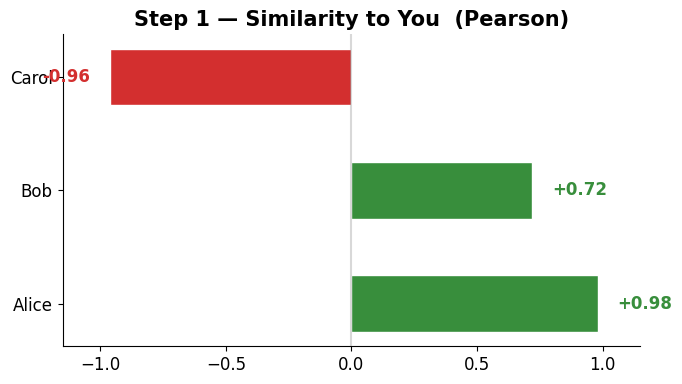

In [21]:
target_user = 3   # "You"
target_item = 2   # "Saw"
you = cf_data[target_user]

similarities = {}
for i in range(3):
    other = cf_data[i]
    mask = ~np.isnan(you) & ~np.isnan(other)
    y, o = you[mask], other[mask]
    y_c, o_c = y - y.mean(), o - o.mean()
    sim = np.dot(y_c, o_c) / (np.linalg.norm(y_c) * np.linalg.norm(o_c))
    similarities[cf_users[i]] = round(sim, 2)

fig, ax = plt.subplots(figsize=(7, 4))
names = list(similarities.keys()); sims = list(similarities.values())
bar_colors = ['#388e3c' if s > 0 else '#d32f2f' for s in sims]
ax.barh(names, sims, color=bar_colors, edgecolor='white', height=0.5)
ax.set_xlim(-1.15, 1.15)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax.set_title('Step 1 — Similarity to You  (Pearson)', fontweight='bold')
for n, s in zip(names, sims):
    ha = 'left' if s >= 0 else 'right'
    ax.text(s + 0.08 * np.sign(s), n, f'{s:+.2f}', va='center', ha=ha,
            fontweight='bold', fontsize=12, color=bar_colors[names.index(n)])
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### Worked example — the neighbours' ratings for *Saw*

Alice and Bob (positive similarity) rated it **low**. Carol (negative similarity) rated it **high** — but her *negative* weight flips that into downward pressure.

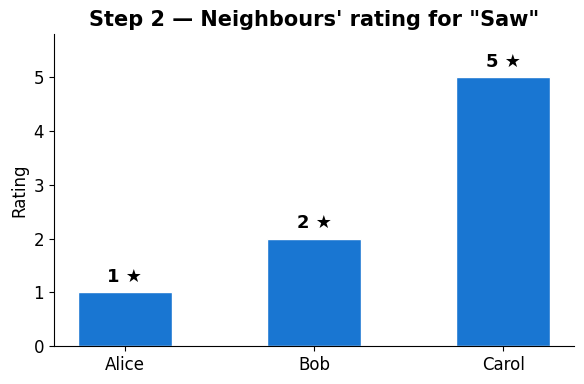

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
saw_ratings = {cf_users[i]: cf_data[i, target_item] for i in range(3)}
names = list(saw_ratings.keys())
ax.bar(names, [saw_ratings[n] for n in names],
       color='#1976d2', edgecolor='white', width=0.5)
ax.set_ylim(0, 5.8)
ax.set_title('Step 2 — Neighbours\' rating for "Saw"', fontweight='bold')
ax.set_ylabel('Rating')
for j, n in enumerate(names):
    ax.text(j, saw_ratings[n] + 0.2, f'{saw_ratings[n]:.0f} ★',
            ha='center', fontweight='bold', fontsize=13)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### Worked example — the predicted rating

Plug the similarities and ratings into the formula. Result: **You probably won't like horror**, because your rating-twins didn't.

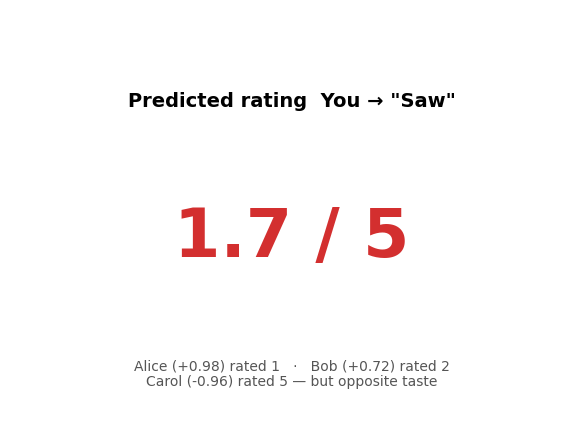

→ Prediction: 1.7/5


In [23]:
mu_you = np.nanmean(you)
numerator, denominator = 0, 0
for i in range(3):
    w = similarities[cf_users[i]]
    mu_v = np.mean(cf_data[i])
    r_vi = cf_data[i, target_item]
    numerator += w * (r_vi - mu_v)
    denominator += abs(w)
predicted = mu_you + numerator / denominator

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.text(0.5, 0.78, 'Predicted rating  You → "Saw"', ha='center', va='center',
        fontsize=14, transform=ax.transAxes, fontweight='bold')
color_pred = '#388e3c' if predicted >= 3 else '#d32f2f'
ax.text(0.5, 0.45, f'{predicted:.1f} / 5', ha='center', va='center',
        fontsize=48, transform=ax.transAxes, fontweight='bold', color=color_pred)
ax.text(0.5, 0.12,
        f'Alice ({similarities["Alice"]:+.2f}) rated 1   ·   Bob ({similarities["Bob"]:+.2f}) rated 2\n'
        f'Carol ({similarities["Carol"]:+.2f}) rated 5 — but opposite taste',
        ha='center', va='center', fontsize=10, transform=ax.transAxes, color='#555')
ax.axis('off')
plt.tight_layout(); plt.show()
print(f'→ Prediction: {predicted:.1f}/5')

### But what about cold start?

CF needs **overlapping ratings** between users. What happens when a user is new?

### Two new users join — Dave and Eve

Dave has rated just one movie. Eve hasn't rated anything yet. The red dashed box shows the "cold start" rows.

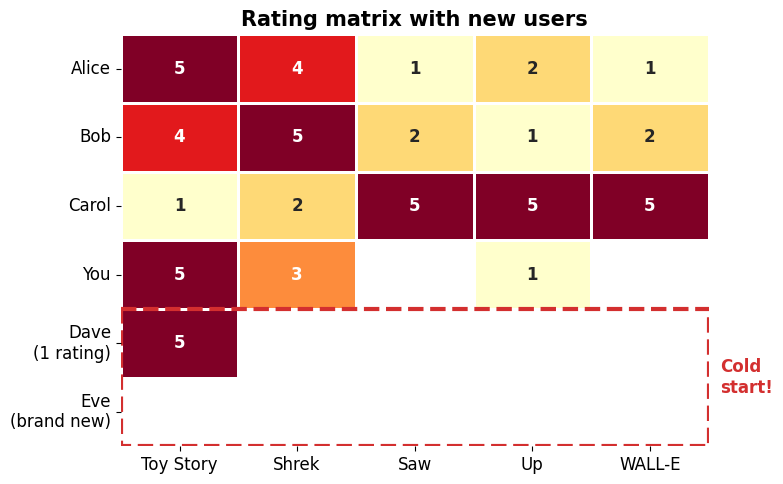

In [24]:
cf_users_cs = ['Alice', 'Bob', 'Carol', 'You', 'Dave\n(1 rating)', 'Eve\n(brand new)']
cf_data_cs = np.array([
    [5,   4,   1,   2,   1],
    [4,   5,   2,   1,   2],
    [1,   2,   5,   5,   5],
    [5,   3, np.nan, 1, np.nan],
    [5, np.nan, np.nan, np.nan, np.nan],
    [np.nan]*5,
])

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(cf_data_cs, annot=True, fmt='.0f', cmap='YlOrRd', cbar=False,
            linewidths=1, linecolor='white', ax=ax,
            xticklabels=cf_movies, yticklabels=cf_users_cs,
            mask=np.isnan(cf_data_cs), annot_kws={'size': 12, 'fontweight': 'bold'})
ax.add_patch(plt.Rectangle((0, 4), 5, 2, fill=False, edgecolor='#d32f2f', lw=3, linestyle='--'))
ax.text(5.1, 5, 'Cold\nstart!', va='center', fontsize=12, fontweight='bold', color='#d32f2f')
ax.set_title('Rating matrix with new users', fontweight='bold')
plt.tight_layout(); plt.show()

### Can CF still find neighbours?

Pearson correlation needs at least 2 co-rated items. Dave has just 1; Eve has 0. **CF is completely blind** for them.

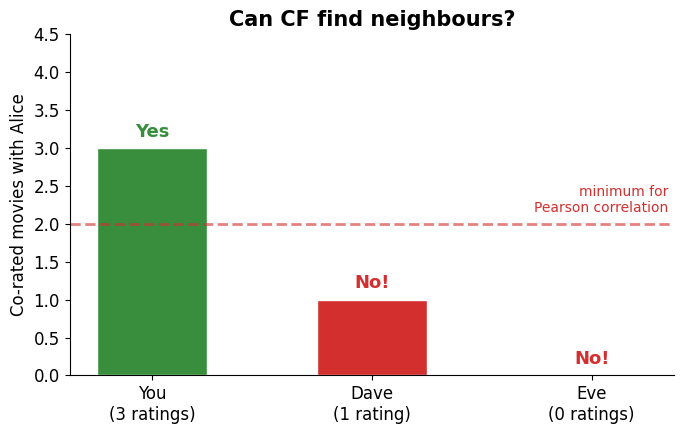

→ Dave: 1 rating → cannot compute similarity.
  Eve: 0 ratings → CF is completely blind.


In [25]:
alice = cf_data_cs[0]
user_labels = ['You\n(3 ratings)', 'Dave\n(1 rating)', 'Eve\n(0 ratings)']
co_rated = []; can_compute = []
for idx in [3, 4, 5]:
    u = cf_data_cs[idx]
    overlap = int(np.sum(~np.isnan(u) & ~np.isnan(alice)))
    co_rated.append(overlap); can_compute.append(overlap >= 2)

fig, ax = plt.subplots(figsize=(7, 4.5))
bar_colors = ['#388e3c' if c else '#d32f2f' for c in can_compute]
bars = ax.bar(user_labels, co_rated, color=bar_colors, edgecolor='white', width=0.5)
ax.axhline(y=2, color='#d32f2f', linestyle='--', linewidth=2, alpha=0.6)
ax.text(2.35, 2.15, 'minimum for\nPearson correlation', fontsize=10, color='#d32f2f', ha='right')
ax.set_ylim(0, 4.5)
ax.set_ylabel('Co-rated movies with Alice')
ax.set_title('Can CF find neighbours?', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
verdicts = ['Yes', 'No!', 'No!']
for bar, v, c in zip(bars, verdicts, bar_colors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            v, ha='center', fontweight='bold', fontsize=13, color=c)
plt.tight_layout(); plt.show()
print('→ Dave: 1 rating → cannot compute similarity.')
print('  Eve: 0 ratings → CF is completely blind.')

Cold start is one of the reasons we'll move beyond the rating matrix in the coming lectures — from hand-crafted feature vectors (L7) to learned latent factors (L8) to neural embeddings (L9–10).

## The Roadmap

From sparse matrix → vectors → learned embeddings → cluster-scale retrieval.

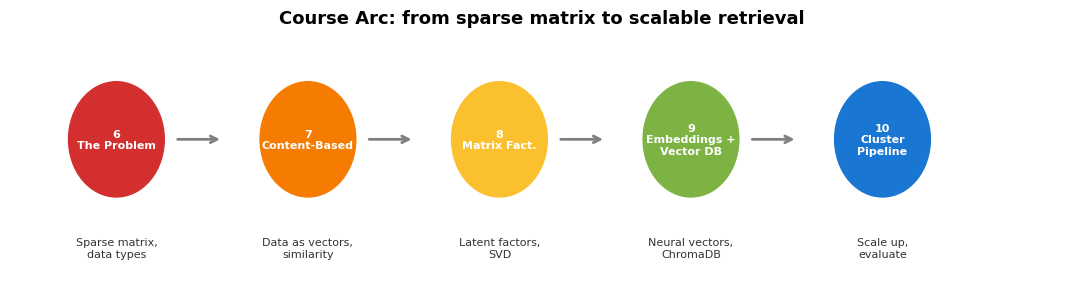

In [26]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 10); ax.set_ylim(0, 2); ax.axis('off')
lectures = [
    ('6\nThe Problem',     '#d32f2f', 'Sparse matrix,\ndata types'),
    ('7\nContent-Based',   '#f57c00', 'Data as vectors,\nsimilarity'),
    ('8\nMatrix Fact.',    '#fbc02d', 'Latent factors,\nSVD'),
    ('9\nEmbeddings +\nVector DB', '#7cb342', 'Neural vectors,\nChromaDB'),
    ('10\nCluster\nPipeline', '#1976d2', 'Scale up,\nevaluate'),
]
for i, (label, color, desc) in enumerate(lectures):
    x = 1 + i * 1.8
    ax.add_patch(plt.Circle((x, 1.2), 0.45, color=color, zorder=3))
    ax.text(x, 1.2, label, ha='center', va='center', fontsize=8, fontweight='bold', color='white', zorder=4)
    ax.text(x, 0.35, desc, ha='center', va='center', fontsize=8, color='#333')
    if i < 4:
        ax.annotate('', xy=(x+1.0, 1.2), xytext=(x+0.55, 1.2),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.set_title('Course Arc: from sparse matrix to scalable retrieval', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout(); plt.show()

## Key Takeaways

1. Recommendation = predicting missing entries in a **very sparse** matrix
2. Data comes in many forms: ratings, text, images, clicks
3. Core challenges: **sparsity**, **long tail**, **cold start**
4. **Collaborative Filtering** uses rating patterns to find similar users — elegant, but breaks on cold start
5. **Path forward:** represent items as **vectors** in a feature space, so we can recommend even without rating overlap → next lecture